# XSA Ablation Plot Notebook

This notebook reads `alpha_gamma_summary.tsv` and produces:
- `fig_alpha_sweep_delta_ppl.png`
- `fig_perp_sweep_delta_ppl.png`
- `fig_alpha_perp_combined.png`


In [1]:
from pathlib import Path
import csv
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# =========================
# File-first configuration
# =========================
SUMMARY_TSV = "/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/results/alpha_gamma_summary.tsv"
OUTPUT_DIR = "/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/figures_xsa_ablation"
FIG_DPI = 300

summary_path = Path(SUMMARY_TSV).expanduser().resolve()
out_dir = Path(OUTPUT_DIR).expanduser().resolve()
out_dir.mkdir(parents=True, exist_ok=True)
print(summary_path)
print(out_dir)

# =========================
# Figure style (paper-like)
# =========================
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#4a4a4a',
    'axes.linewidth': 1.0,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'legend.frameon': False,
    'grid.color': '#d0d0d0',
    'grid.alpha': 0.45,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'lines.linewidth': 2.2,
    'lines.markersize': 5.5,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.06,
})

C_MEAN = '#1f77b4'
C_WORST = '#d62728'
C_WIN = '#2ca02c'
C_REF = '#6e6e6e'


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/bytedance/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/bytedance/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/bytedance/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/bytedance/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/bytedance/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 649, in get
    value = self._v

/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/results/alpha_gamma_summary.tsv
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/figures_xsa_ablation


In [2]:
def _to_float(x: str):
    s = (x or '').strip()
    if s == '':
        return None
    try:
        return float(s)
    except Exception:
        return None

def _load_rows(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return list(csv.DictReader(f, delimiter='\t'))

def _select_alpha_sweep(rows):
    out = []
    for r in rows:
        if r.get('setting_type', '') != 'alpha':
            continue
        alpha = _to_float(r.get('alpha', ''))
        perp = _to_float(r.get('perp', ''))
        m = _to_float(r.get('mean_delta_ppl', ''))
        w = _to_float(r.get('worst_case_delta_ppl', ''))
        wr = _to_float(r.get('win_rate_delta_ppl_lt_0', ''))
        if alpha is None or perp is not None or m is None or w is None:
            continue
        out.append({'alpha': alpha, 'mean_delta_ppl': m, 'worst_case_delta_ppl': w, 'win_rate': 0.0 if wr is None else wr})
    out.sort(key=lambda x: x['alpha'])
    return out

def _select_perp_sweep_alpha_fixed(rows, alpha_target=1.0):
    out = []
    for r in rows:
        if r.get('setting_type', '') != 'alpha':
            continue
        alpha = _to_float(r.get('alpha', ''))
        perp = _to_float(r.get('perp', ''))
        m = _to_float(r.get('mean_delta_ppl', ''))
        w = _to_float(r.get('worst_case_delta_ppl', ''))
        wr = _to_float(r.get('win_rate_delta_ppl_lt_0', ''))
        if alpha is None or perp is None or m is None or w is None:
            continue
        if abs(alpha - alpha_target) > 1e-8:
            continue
        out.append({'perp': perp, 'mean_delta_ppl': m, 'worst_case_delta_ppl': w, 'win_rate': 0.0 if wr is None else wr})
    out.sort(key=lambda x: x['perp'])
    return out

rows = _load_rows(summary_path)
alpha_rows = _select_alpha_sweep(rows)
perp_rows = _select_perp_sweep_alpha_fixed(rows, alpha_target=1.0)
print('alpha_points:', len(alpha_rows))
print('perp_points(alpha=1.0):', len(perp_rows))

alpha_points: 17
perp_points(alpha=1.0): 15


In [3]:
def _clean_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y')


def _plot_alpha_sweep(alpha_rows, out_dir: Path):
    xs = [r['alpha'] for r in alpha_rows]
    ys_mean = [r['mean_delta_ppl'] for r in alpha_rows]
    ys_worst = [r['worst_case_delta_ppl'] for r in alpha_rows]
    ys_win = [100.0 * r['win_rate'] for r in alpha_rows]

    fig, ax1 = plt.subplots(figsize=(8.8, 5.0))
    ax1.plot(xs, ys_mean, marker='o', color=C_MEAN, label='Mean $\Delta$PPL')
    ax1.plot(xs, ys_worst, marker='s', color=C_WORST, label='Worst-case $\Delta$PPL')
    ax1.axhline(0.0, color=C_REF, linestyle='--', linewidth=1.0)
    ax1.axvline(1.0, color=C_REF, linestyle=':', linewidth=1.0)
    ax1.set_xlabel('Parallel Removal Strength $\alpha$')
    ax1.set_ylabel('$\Delta$PPL')
    ax1.set_title('Parallel-Component Robustness (Alpha Sweep)')
    _clean_axes(ax1)

    ax2 = ax1.twinx()
    ax2.plot(xs, ys_win, marker='^', color=C_WIN, linewidth=2.0, label='Win-rate (%)')
    ax2.set_ylabel('Win-rate (%)')
    ax2.set_ylim(0, 100)
    ax2.spines['top'].set_visible(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', ncol=1)

    out = out_dir / 'fig_alpha_sweep_delta_ppl.png'
    fig.savefig(out, dpi=FIG_DPI)
    plt.close(fig)
    return out


def _plot_perp_sweep(perp_rows, out_dir: Path, alpha_fixed=1.0):
    xs = [r['perp'] for r in perp_rows]
    ys_mean = [r['mean_delta_ppl'] for r in perp_rows]
    ys_worst = [r['worst_case_delta_ppl'] for r in perp_rows]
    ys_win = [100.0 * r['win_rate'] for r in perp_rows]

    fig, ax1 = plt.subplots(figsize=(8.8, 5.0))
    ax1.plot(xs, ys_mean, marker='o', color=C_MEAN, label='Mean $\Delta$PPL')
    ax1.plot(xs, ys_worst, marker='s', color=C_WORST, label='Worst-case $\Delta$PPL')
    ax1.axhline(0.0, color=C_REF, linestyle='--', linewidth=1.0)
    ax1.axvline(1.0, color=C_REF, linestyle=':', linewidth=1.0, label='No Perp Scaling')
    ax1.set_xlabel('Perpendicular Keep Factor')
    ax1.set_ylabel('$\Delta$PPL')
    ax1.set_title(f'Perpendicular-Component Sensitivity ($\alpha={alpha_fixed:g}$)')
    _clean_axes(ax1)

    ax2 = ax1.twinx()
    ax2.plot(xs, ys_win, marker='^', color=C_WIN, linewidth=2.0, label='Win-rate (%)')
    ax2.set_ylabel('Win-rate (%)')
    ax2.set_ylim(0, 100)
    ax2.spines['top'].set_visible(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', ncol=1)

    out = out_dir / 'fig_perp_sweep_delta_ppl.png'
    fig.savefig(out, dpi=FIG_DPI)
    plt.close(fig)
    return out


def _plot_combined(alpha_rows, perp_rows, out_dir: Path):
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)

    ax = axes[0]
    ax.plot([r['alpha'] for r in alpha_rows], [r['mean_delta_ppl'] for r in alpha_rows], marker='o', color=C_MEAN, label='Mean $\Delta$PPL')
    ax.plot([r['alpha'] for r in alpha_rows], [r['worst_case_delta_ppl'] for r in alpha_rows], marker='s', color=C_WORST, label='Worst-case $\Delta$PPL')
    ax.axhline(0.0, color=C_REF, linestyle='--', linewidth=1.0)
    ax.axvline(1.0, color=C_REF, linestyle=':', linewidth=1.0)
    ax.set_xlabel('$\alpha$')
    ax.set_ylabel('$\Delta$PPL')
    ax.set_title('Alpha Sweep')
    _clean_axes(ax)

    ax = axes[1]
    ax.plot([r['perp'] for r in perp_rows], [r['mean_delta_ppl'] for r in perp_rows], marker='o', color=C_MEAN, label='Mean $\Delta$PPL')
    ax.plot([r['perp'] for r in perp_rows], [r['worst_case_delta_ppl'] for r in perp_rows], marker='s', color=C_WORST, label='Worst-case $\Delta$PPL')
    ax.axhline(0.0, color=C_REF, linestyle='--', linewidth=1.0)
    ax.axvline(1.0, color=C_REF, linestyle=':', linewidth=1.0)
    ax.set_xlabel('Perp Keep')
    ax.set_ylabel('$\Delta$PPL')
    ax.set_title('Perp Sweep ($\alpha=1$)')
    _clean_axes(ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.03))

    out = out_dir / 'fig_alpha_perp_combined.png'
    fig.savefig(out, dpi=FIG_DPI)
    plt.close(fig)
    return out


p1 = _plot_alpha_sweep(alpha_rows, out_dir)
p2 = _plot_perp_sweep(perp_rows, out_dir, alpha_fixed=1.0)
p3 = _plot_combined(alpha_rows, perp_rows, out_dir)
print(p1)
print(p2)
print(p3)


/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/figures_xsa_ablation/fig_alpha_sweep_delta_ppl.png
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/figures_xsa_ablation/fig_perp_sweep_delta_ppl.png
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/figures_xsa_ablation/fig_alpha_perp_combined.png


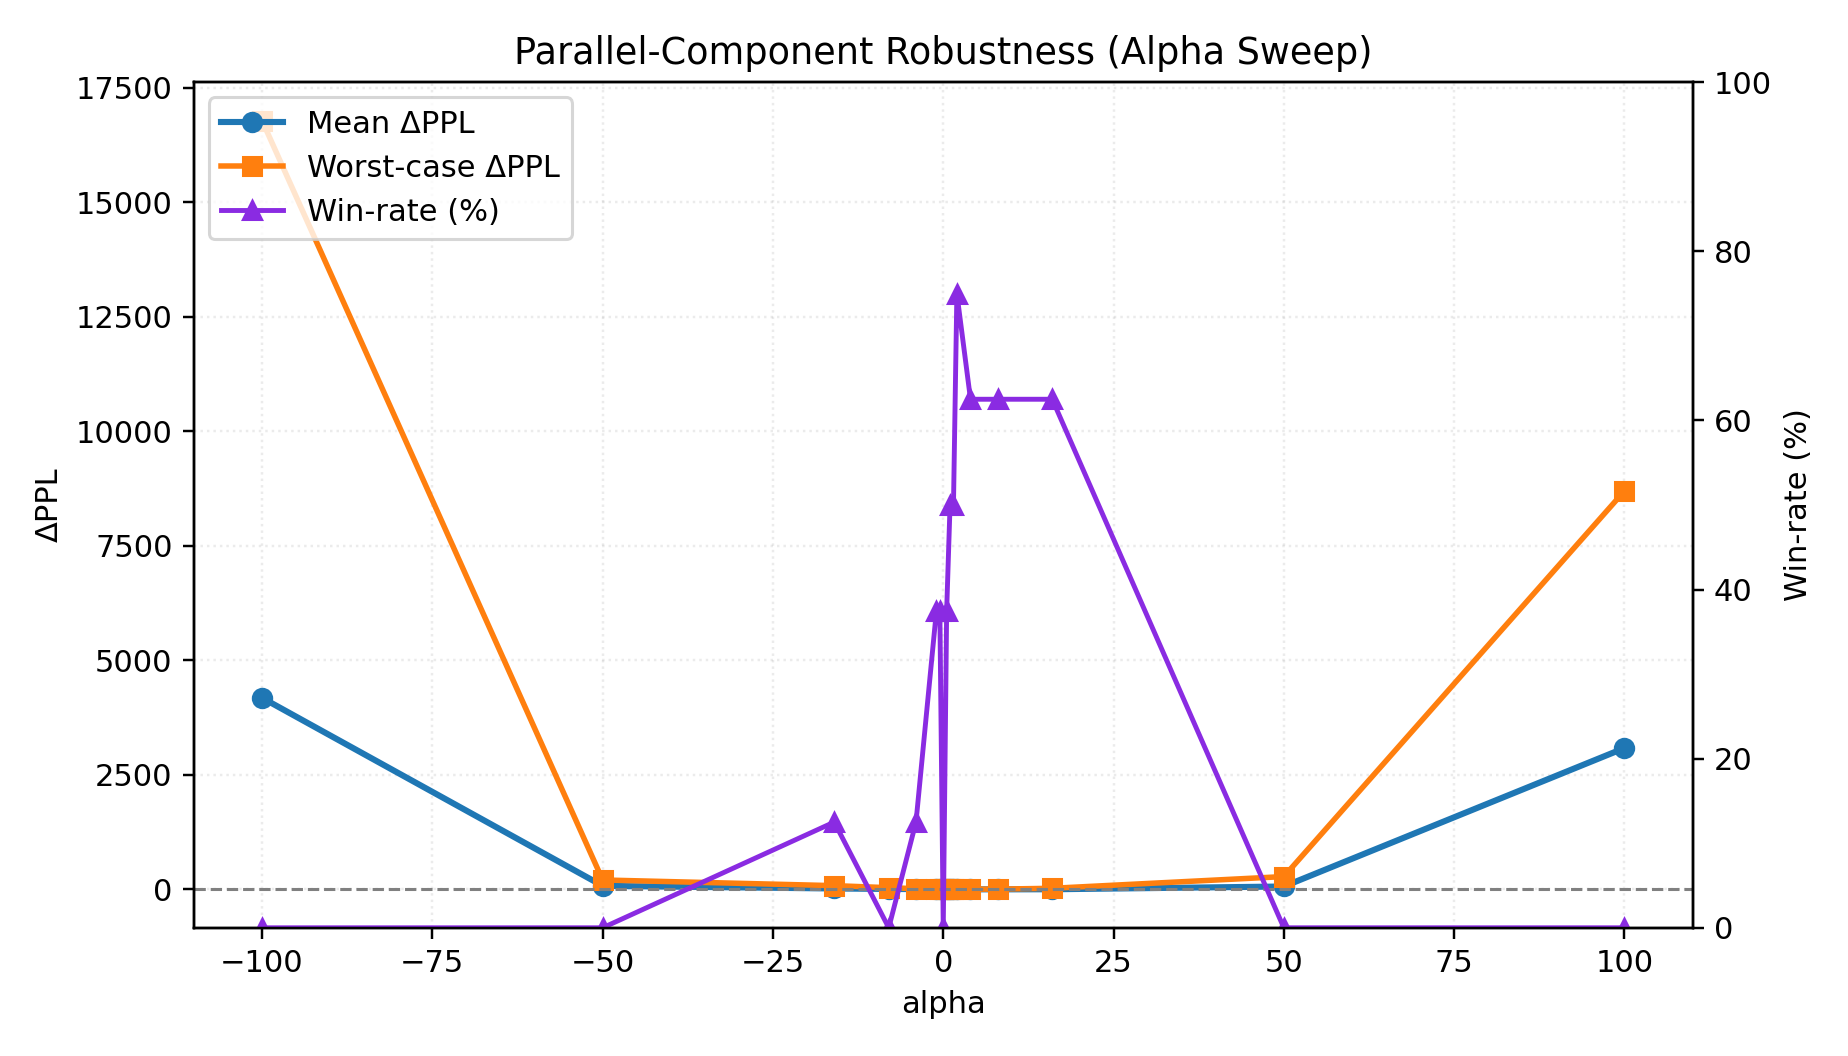

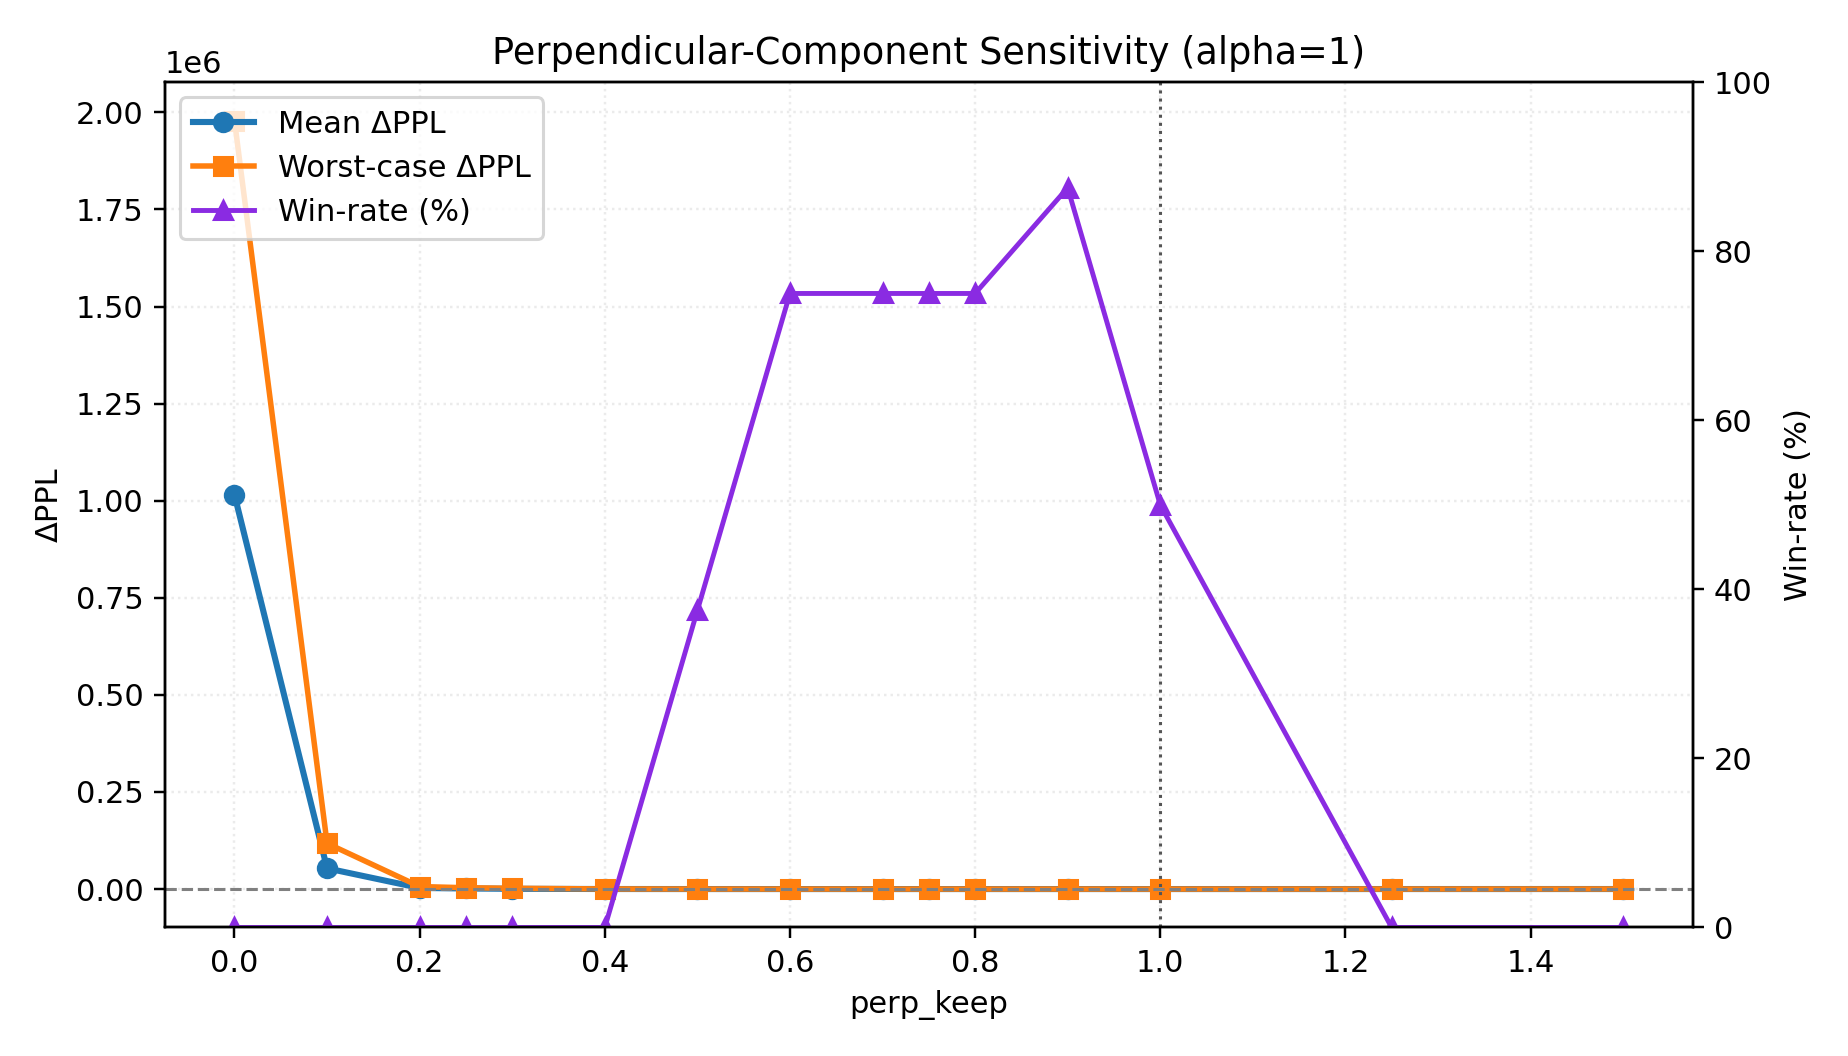

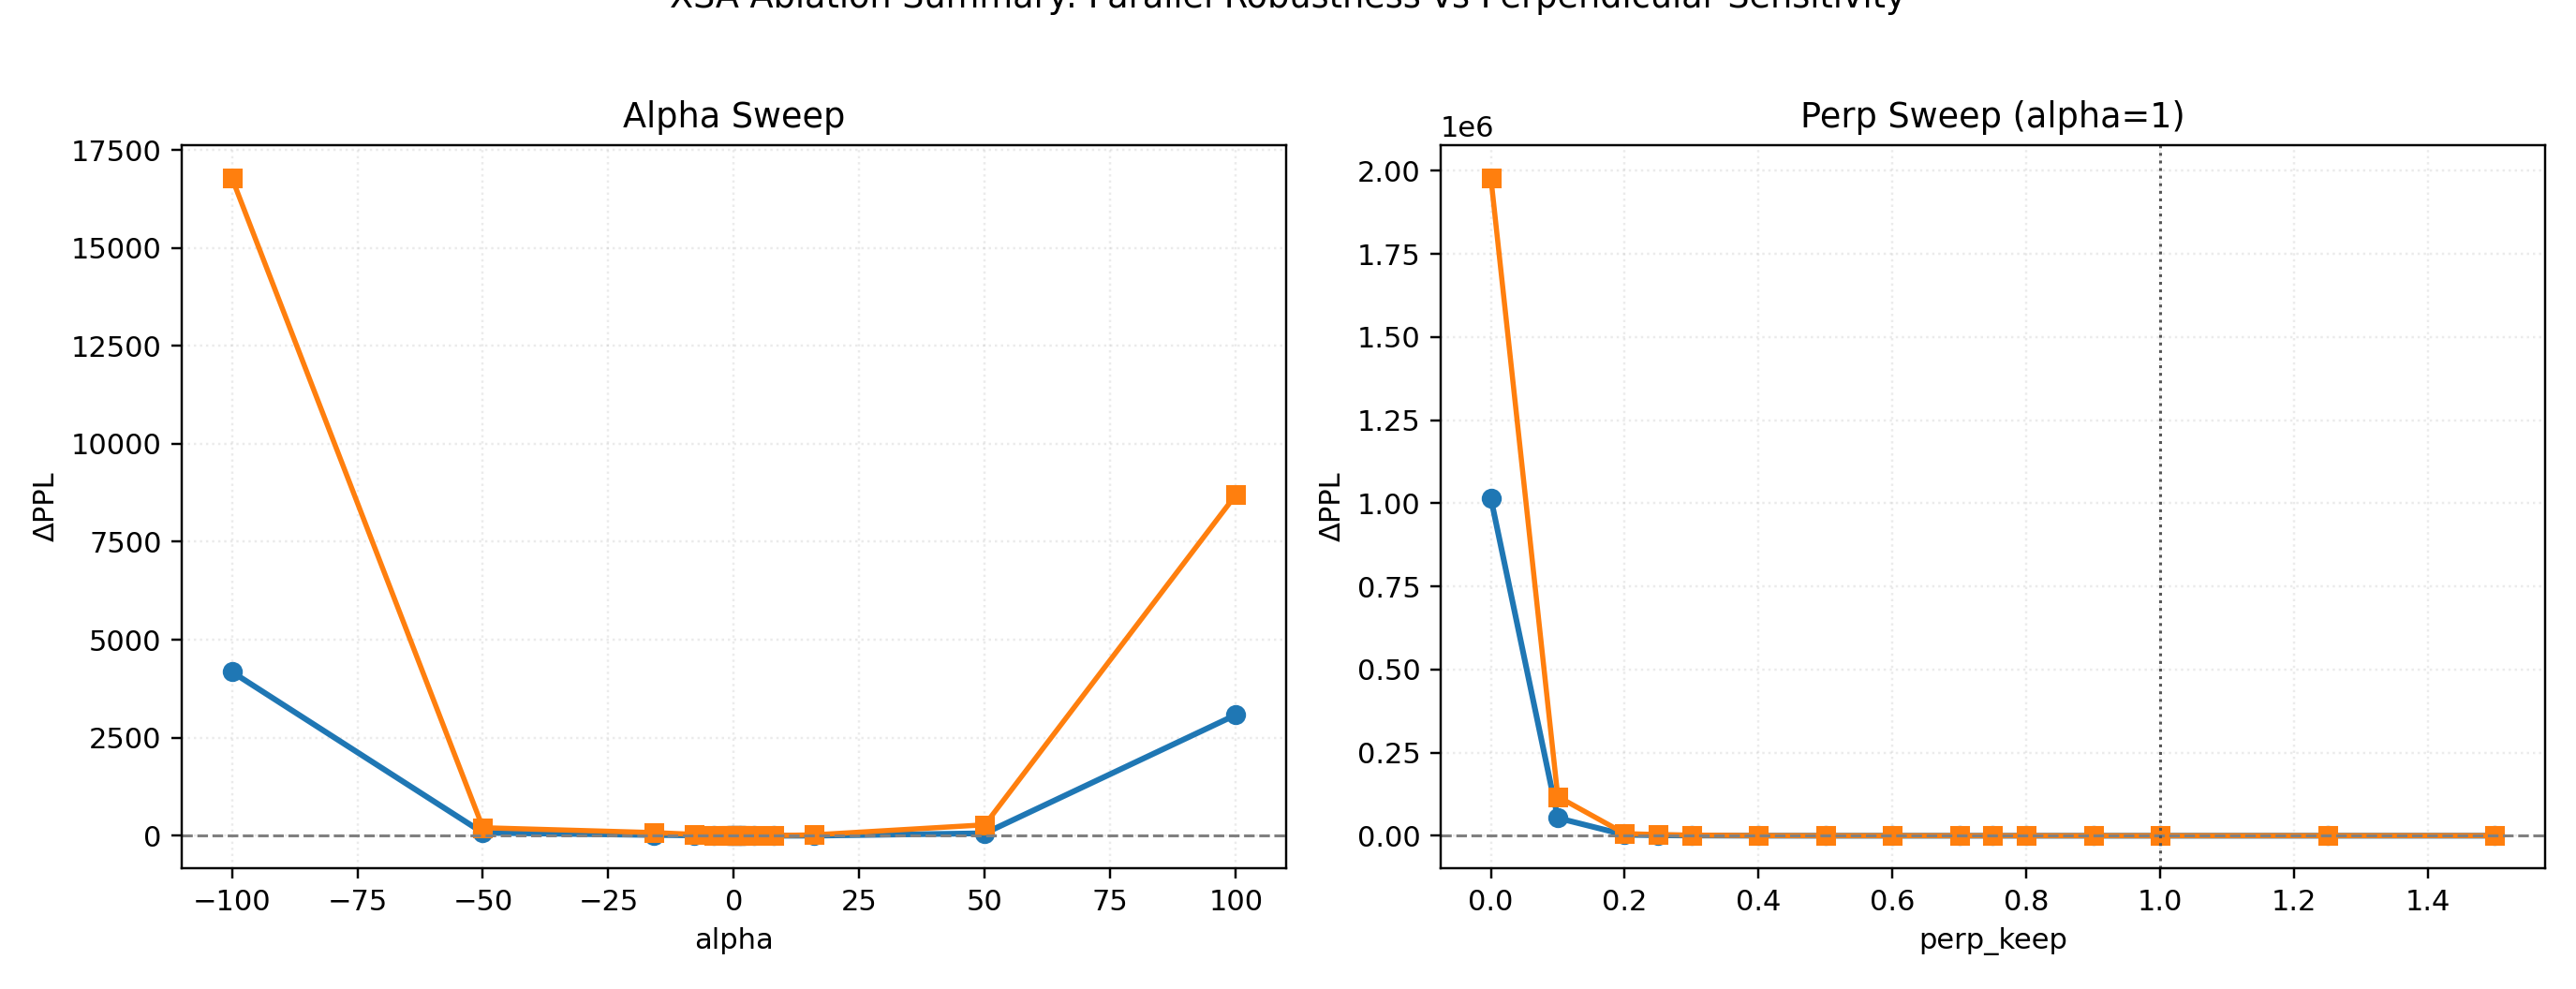

In [4]:
from IPython.display import Image, display
display(Image(filename=str(out_dir / 'fig_alpha_sweep_delta_ppl.png')))
display(Image(filename=str(out_dir / 'fig_perp_sweep_delta_ppl.png')))
display(Image(filename=str(out_dir / 'fig_alpha_perp_combined.png')))